# EDA, Stratification, and Logistic Regression in the Credit Card Fraud Dataset 

## **1. Exploratory Data Analysis**

In [1]:
import kagglehub
import os

# Download the latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

csv_path = os.path.join(path, "creditcard.csv")

c:\Users\Usuario\Documents\YachayTech\Eigth_semester\machine_learning\Machine-learning-course-Yachay\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

creditcard_df = pd.read_csv(csv_path)

raw_creditcard_df = creditcard_df.copy()

#### **1.1 Initial exploration about dimension, data types, null and duplicated values**

The first step that I want to do is analyze the following information:
- Number total of records
- Number of columns and the data type of each one
- Number of null and duplicated values

In [3]:
print(f"Total Number of records on the dataset {creditcard_df.shape[0]}\n")
print(f"Number of columns: {len(list(creditcard_df.columns))}\n")
print("Data types of the columns\n")
creditcard_df.info()

Total Number of records on the dataset 284807

Number of columns: 31

Data types of the columns

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  

With the above output we can see the following number of data types:
- one ``int64`` data type
- zero `str` data types
- thirty `float64` data types

---

In [4]:
# Analyze the total number of Null Values in each column of the dataset

creditcard_df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
# Analyze the total of duplicates on the dataset

creditcard_df.duplicated().sum()

np.int64(1081)

Above information show us that we don't have any columns with null values which are a good news about our quality of the data. However, in the other hand, respecto to **duplicate values**, we have evidence by the code (`DataFraduplicated().sum()`), that we have a total of $1081$ duplicated values. Let's explore with a quick visualization about it data.

In [6]:
creditcard_df[creditcard_df.duplicated(keep=False)].head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


When we have duplicated data is necessary to drop from our dataset, because can make noise to the model, and also we know that the total of our registers are $284807$, but the total number of duplicated values are $1081$ which are only the $0.03796\%$, so drop that data would not result in a significant change to the model, unlike if we decided to keep them.

In [7]:
creditcard_df = creditcard_df.drop_duplicates(keep='first')

print(f"Total Number of records on the dataset {creditcard_df.shape[0]}\n")

Total Number of records on the dataset 283726



### **1.2 Descriptive statistics about dataset**

We have a lot of numeric variables, a good way to do an analysis about descriptive statistics are using `DataFrame.describe()` method, which give us information about:
- mean
- standard desviation
- minimum value
- maximum value
- quartiles

These information are useful to know for example which scaler method we have to use in our colums. For example the most critical feature with a problem of scaling are `amout`, where the minimun value are very low ($0$) compared to its maximum value ($25,691.160000$), which affects statistics such as its *mean* and *standard deviation*. For this column, for example, it is necessary to apply an appropriate scaling technique to preserve the patterns revealed by them.

Some utils scalers for this dataset are: *Logarithmic transform* or *Robust Scaler*

In [8]:
creditcard_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


### **1.3 Target variable distribution (proportion)**

In [9]:
print("Distribution respect to total number of transaction on the dataset\n")
print(creditcard_df['Class'].value_counts())

Distribution respect to total number of transaction on the dataset

Class
0    283253
1       473
Name: count, dtype: int64


In [10]:
print("Distribution respect to total number of transaction on the dataset (PERCENTAGE)\n")
print(creditcard_df['Class'].value_counts(normalize=True) * 100)

Distribution respect to total number of transaction on the dataset (PERCENTAGE)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


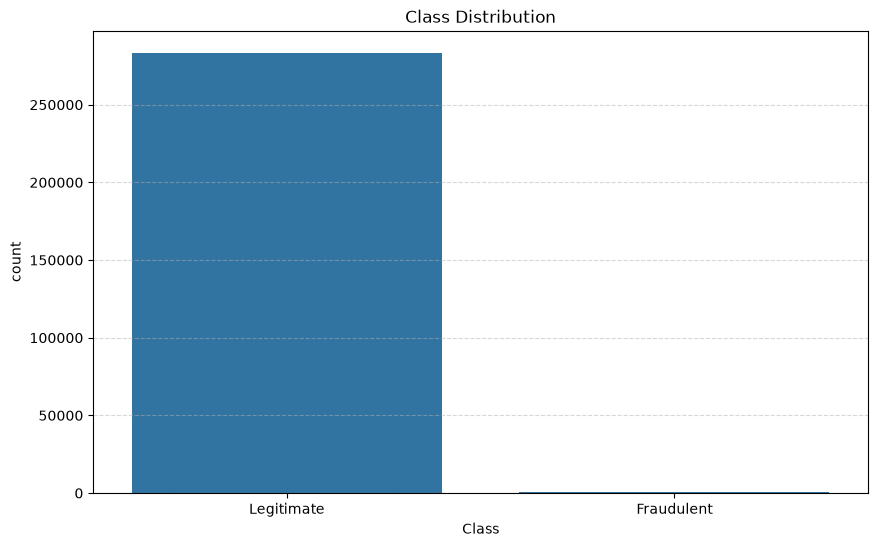

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(x='Class', data=creditcard_df)
plt.title('Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

We can see that our dataset is extremely unbalanced, this could be cause problems in our machine learning model, where our model learns perfectly the pattern of the majority class showing a good metrics post-training only on the majority class, but no in the minority. That discussion we will address in the final section of this notebook.

---

### **1.4 Behavaior and distribution of the main variables**

In this section, I'm going to make some plots which could be useful for understanding the data

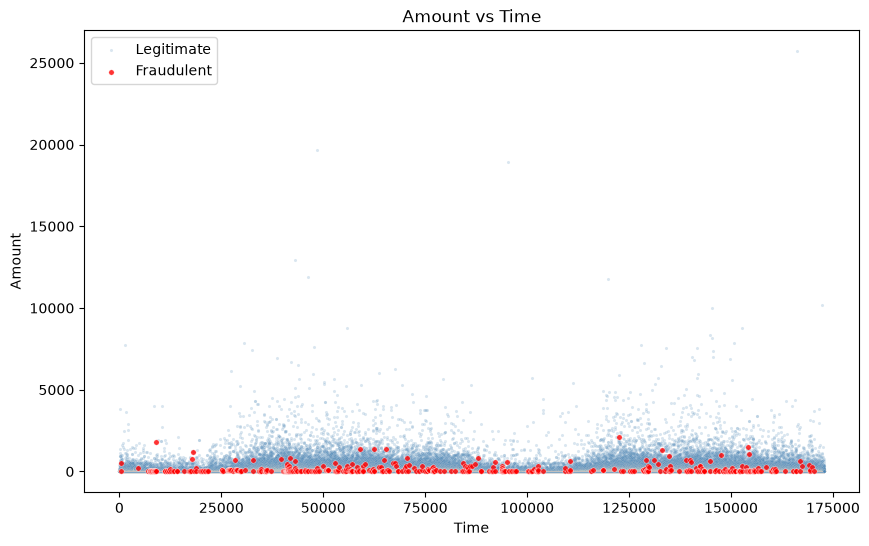

In [12]:
fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(data=creditcard_df[creditcard_df['Class']==0],
                 x='Time', y='Amount', color='steelblue',
                 alpha=0.2, s=5, label='Legitimate', ax=ax)

sns.scatterplot(data=creditcard_df[creditcard_df['Class']==1],
                 x='Time', y='Amount', color='red',
                 alpha=0.8, s=15, label='Fraudulent', ax=ax)

ax.set_title('Amount vs Time')
plt.show()

When we generate a graph (``Time`` x `Quantity`), we can see that the fraudulent data exhibits a pattern that does not include outliers that deviate significantly from the majority of the data, unlike the legitimate data; this helps us determine that there is a real difference between the two classes when we analyze the quantity. To see with a more valuable matter about the outilers, we can use the boxplots for each class.

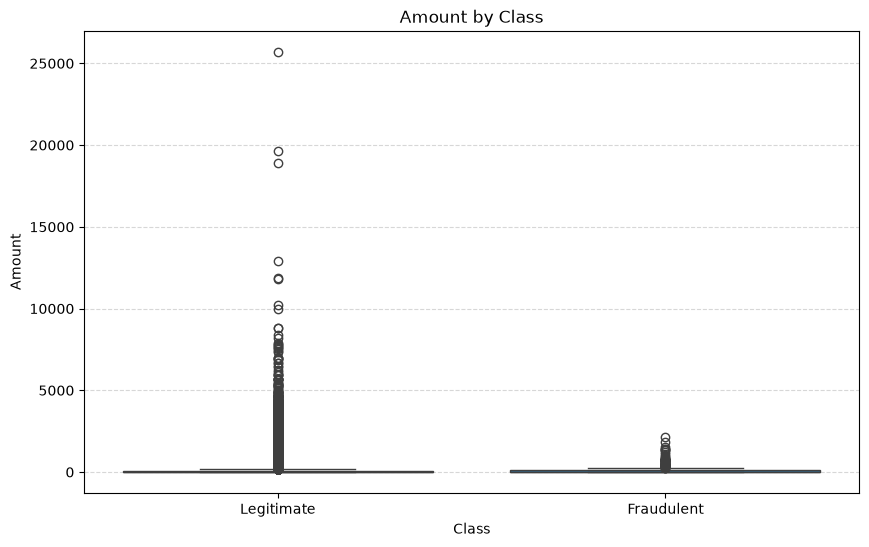

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Class', y='Amount', data=creditcard_df)
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.title('Amount by Class')
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In fact, the outliers in the fraudulent class are very close to one another, unlike those in the legitimate class, which are not. Furthermore, we can analyze the data using a time-series analysis with `kdeplots`, and the information provided by these graphs is quite interesting. We can see that a fraudulent transaction is most likely to occur in the early morning, between ``12:00 AM`` and ``6:00 AM`` on the two days, when most people are asleep. Similarly, in the graph where the X-axis is plotted in seconds, there are two peaks where fraudulent transactions are most likely to occur.

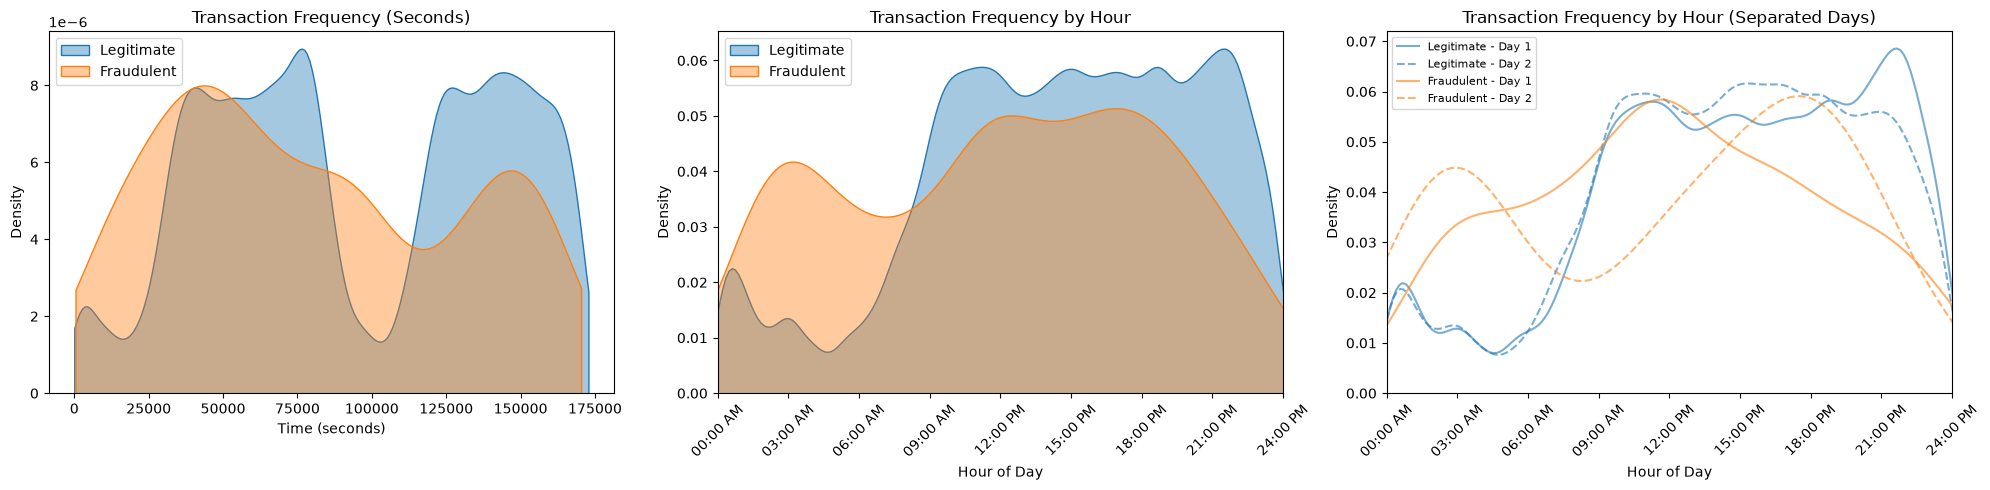

In [32]:
creditcard_df['Day'] = (creditcard_df['Time'] // 86400).astype(int)  # 0 = day 1, 1 = day 2
creditcard_df['Hour'] = (creditcard_df['Time'] / 3600) % 24

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Raw seconds
for cls, label in [(0, 'Legitimate'), (1, 'Fraudulent')]:
    subset = creditcard_df[creditcard_df['Class'] == cls]['Time']
    sns.kdeplot(subset, label=label, fill=True, alpha=0.4, ax=axes[0], cut=0)
axes[0].set_title('Transaction Frequency (Seconds)')
axes[0].set_xlabel('Time (seconds)')
axes[0].legend()

# Plot 2: Hour of a one day
for cls, label in [(0, 'Legitimate'), (1, 'Fraudulent')]:
    subset = creditcard_df[creditcard_df['Class'] == cls]['Hour']
    sns.kdeplot(subset, label=label, fill=True, alpha=0.4, ax=axes[1])
axes[1].set_title('Transaction Frequency by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_xlim(0, 24)
axes[1].set_xticks(range(0, 25, 3))
axes[1].set_xticklabels(
    [f"{h:02d}:00 {'AM' if h < 12 else 'PM'}" for h in range(0, 25, 3)],
    rotation=45
)
axes[1].legend()

# Plot 3: Hour of day, separated by day
colors = {0: 'tab:blue', 1: 'tab:orange'}
linestyles = {0: '-', 1: '--'}
labels_cls = {0: 'Legitimate', 1: 'Fraudulent'}

for cls in [0, 1]:
    for day in [0, 1]:
        subset = creditcard_df[(creditcard_df['Class'] == cls) & (creditcard_df['Day'] == day)]['Hour']
        sns.kdeplot(subset, ax=axes[2], color=colors[cls], linestyle=linestyles[day],
                    label=f"{labels_cls[cls]} - Day {day+1}", alpha=0.6)

axes[2].set_title('Transaction Frequency by Hour (Separated Days)')
axes[2].set_xlabel('Hour of Day')
axes[2].set_xlim(0, 24)
axes[2].set_xticks(range(0, 25, 3))
axes[2].set_xticklabels(
    [f"{h:02d}:00 {'AM' if h < 12 else 'PM'}" for h in range(0, 25, 3)],
    rotation=45
)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---

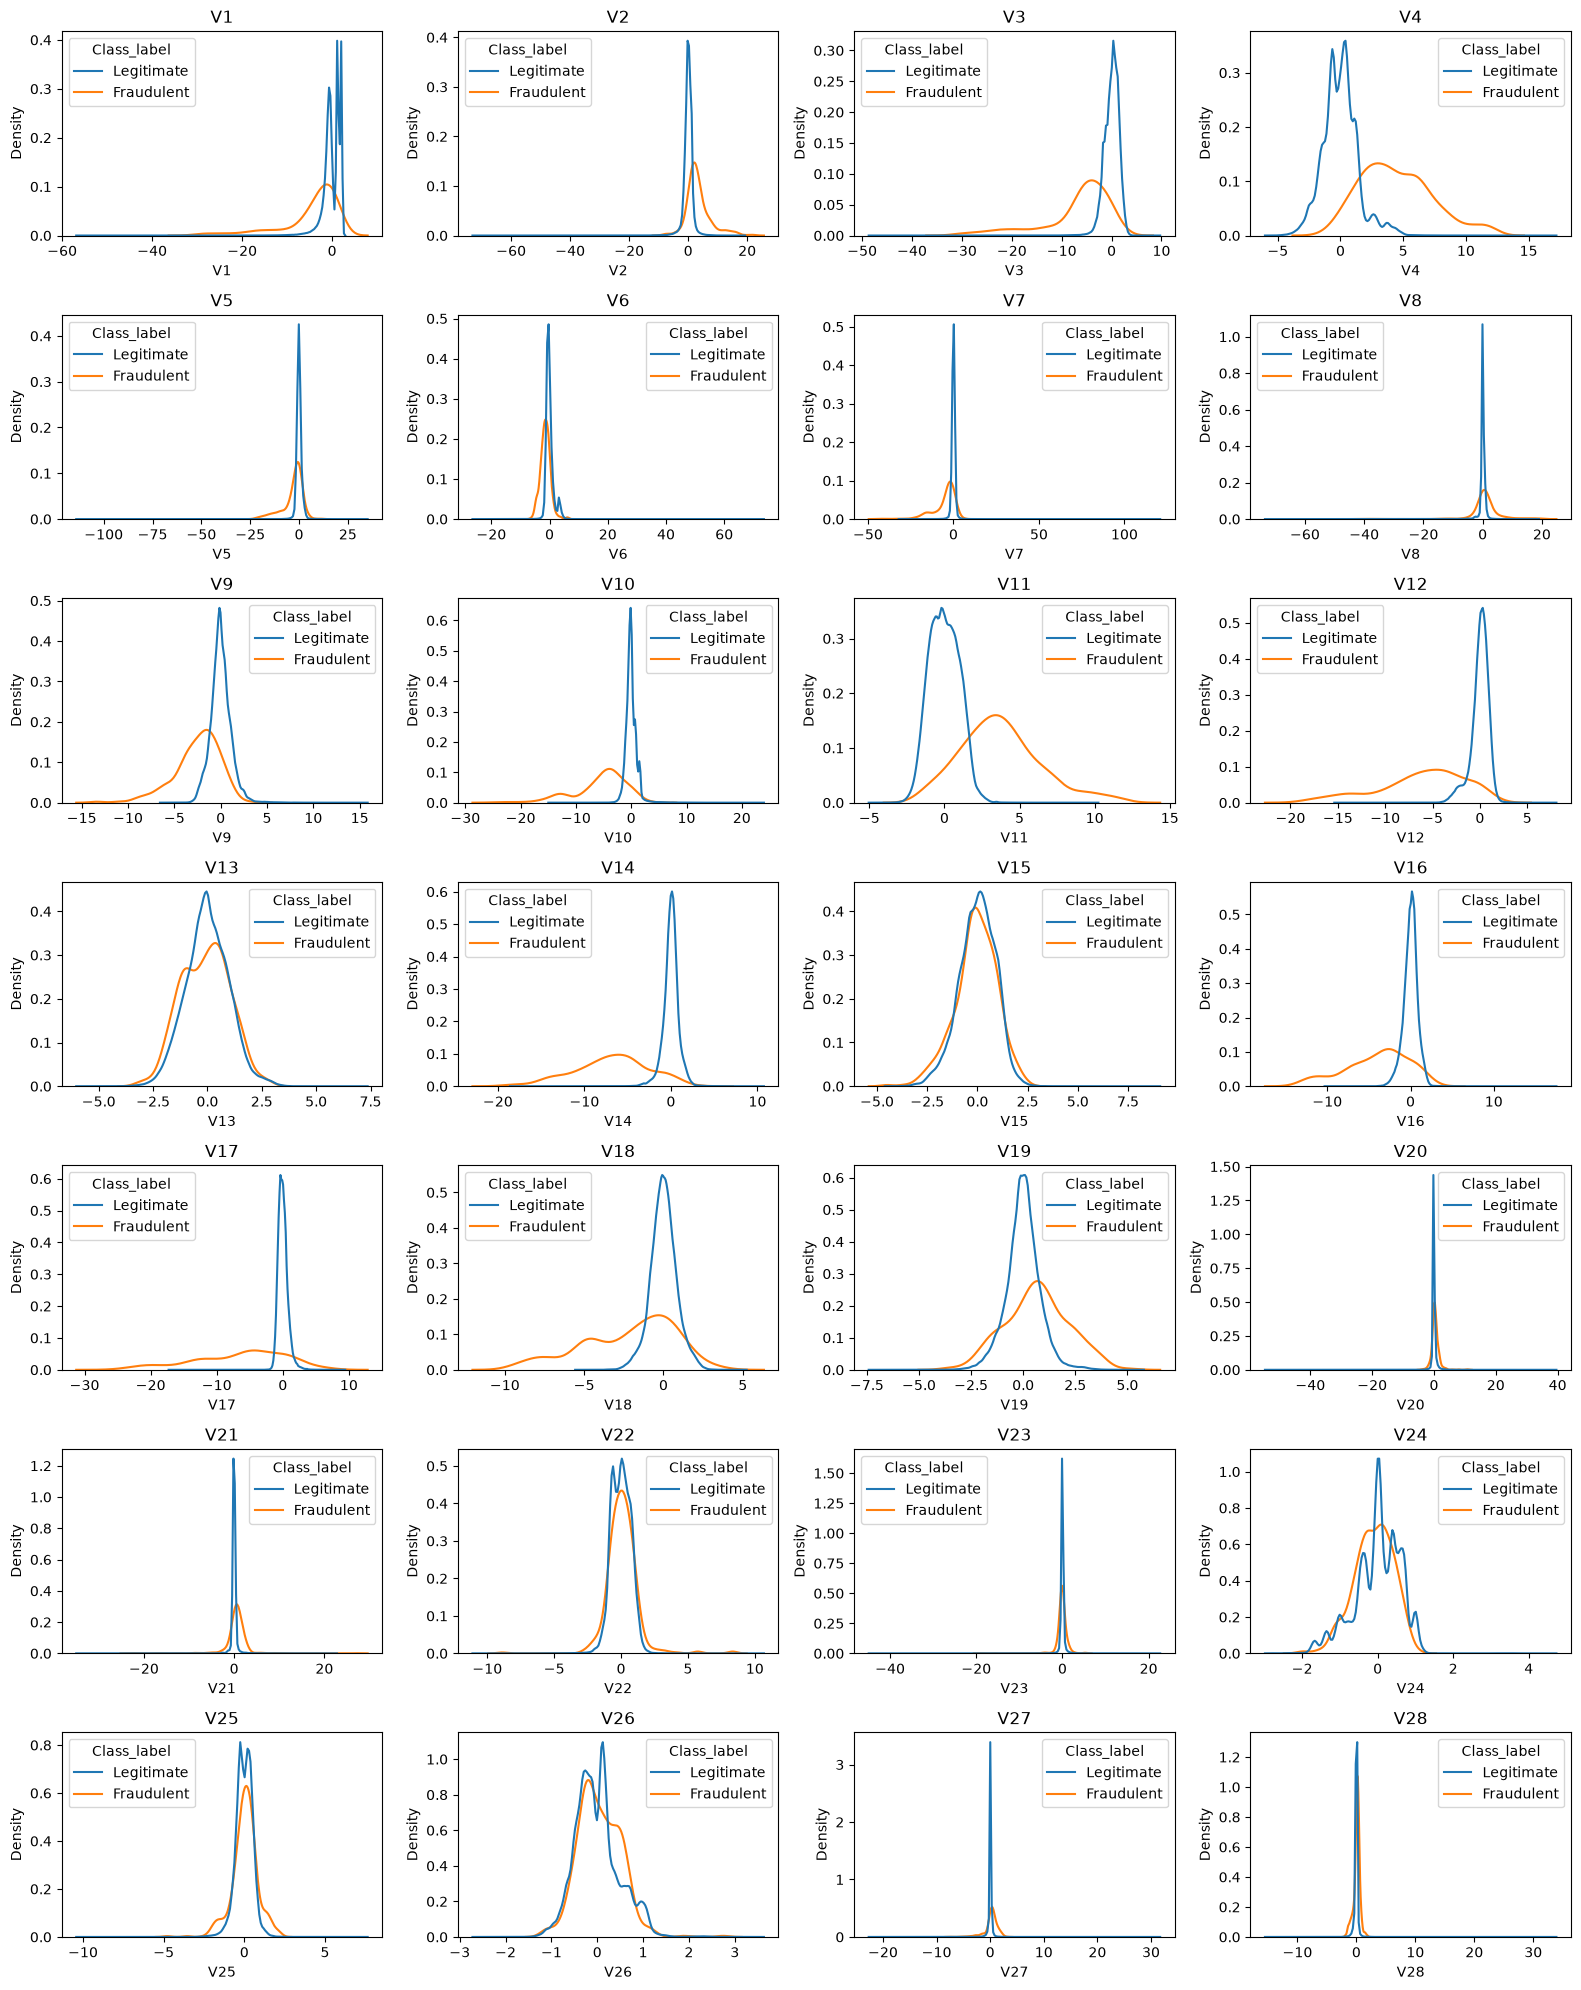

In [34]:
v_cols = [f'V{i}' for i in range(1, 29)]
creditcard_df['Class_label'] = creditcard_df['Class'].map({0: 'Legitimate', 1: 'Fraudulent'})

fig, axes = plt.subplots(7, 4, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    sns.kdeplot(data=creditcard_df, x=col, hue='Class_label',
                common_norm=False, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Plotting the distribution of each V variable separately for the legitimate and fraudulent classes reveals which components discriminate well between the two: when the two curves are clearly separated, that variable alone carries strong predictive signal (e.g. `V3`, `V9`, `V10`, `V11`, `V12`, etc.), while heavy overlap suggests the variable is not discriminative on its own (though it may still contribute in combination with others).

---